In [1]:
from pandas import Series, DataFrame
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import sklearn.metrics
# Feature Importance
from sklearn import datasets
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#load dataset gaminder 
AH_data=pd.read_csv('_42502e10d1b8ccdf0176b401a3b527c4_gapminder.csv')

#replacing empty strings with Nan and Numeric conversion
AH_data.replace('', np.nan, inplace=True)
AH_data.replace(' ', np.nan, inplace=True)

for col in AH_data.columns:
    if col != 'country':
        AH_data[col] = pd.to_numeric(AH_data[col], errors='coerce')

#finding median on binary target variable
median_internet = AH_data['internetuserate'].median()
AH_data['TREG1'] = (AH_data['internetuserate'] > median_internet).astype(int)

#processing data cleaning to drop missing rows
data_clean = AH_data.dropna()

print("Dataset cleaned and prepared.")
print(f"Number of observations: {len(data_clean)}")
print(f"Binary target distribution:\n{data_clean['TREG1'].value_counts()}")

Dataset cleaned and prepared.
Number of observations: 56
Binary target distribution:
1    43
0    13
Name: TREG1, dtype: int64


In [3]:
data_clean.dtypes

country                  object
incomeperperson         float64
alcconsumption          float64
armedforcesrate         float64
breastcancerper100th    float64
co2emissions            float64
femaleemployrate        float64
hivrate                 float64
internetuserate         float64
lifeexpectancy          float64
oilperperson            float64
polityscore             float64
relectricperperson      float64
suicideper100th         float64
employrate              float64
urbanrate               float64
TREG1                     int64
dtype: object

In [4]:
data_clean.describe()

,incomeperperson,alcconsumption,armedforcesrate,breastcancerper100th,co2emissions,femaleemployrate,hivrate,internetuserate,lifeexpectancy,oilperperson,polityscore,relectricperperson,suicideper100th,employrate,urbanrate,TREG1
count,56.000000,56.000000,56.000000,56.000000,5.600000e+01,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,12982.654643,9.429107,1.264465,50.233929,1.676553e+10,47.044643,0.572321,52.464245,75.497446,1.277555,6.142857,1461.149633,11.076095,57.491072,68.072143,0.767857
std,12712.681024,5.266750,1.072482,24.990276,4.687420e+10,10.781329,2.358642,26.218205,5.787174,1.709368,5.940397,1470.378386,6.984522,7.559035,16.572755,0.426021
min,558.062877,0.050000,0.287892,16.600000,2.262553e+08,18.200001,0.060000,3.700003,52.797000,0.032281,-10.000000,68.115229,1.380965,41.099998,27.140000,0.000000
25%,2532.598585,6.417500,0.525650,30.675000,1.859310e+09,41.999999,0.100000,33.049632,73.091750,0.441491,5.000000,494.648726,5.983114,52.175000,60.935000,1.000000
50%,6219.692968,10.035000,0.964324,46.100000,3.852409e+09,48.299999,0.150000,48.980090,75.766500,0.835665,9.000000,875.419623,9.993177,58.150002,68.570000,1.000000
75%,25373.478550,13.135000,1.625027,74.500000,1.135942e+10,54.374999,0.400000,77.533598,80.578250,1.570551,10.000000,1896.710910,13.750678,62.325000,78.210000,1.000000
max,39972.352768,19.150000,6.394936,101.100000,3.342209e+11,68.900002,17.800000,93.277508,83.394000,12.228645,10.000000,7432.130852,33.341860,76.000000,100.000000,1.000000


In [5]:
#spliting into training and test sets
predictors = data_clean[['incomeperperson','alcconsumption','armedforcesrate',
'breastcancerper100th','co2emissions','femaleemployrate','hivrate',
'lifeexpectancy','oilperperson','polityscore','relectricperperson',
'suicideper100th','employrate','urbanrate']]

targets = data_clean.TREG1

pred_train, pred_test, tar_train, tar_test = train_test_split(predictors, targets, test_size=.4)

In [6]:
pred_train.shape

(33, 14)

In [7]:
pred_test.shape

(23, 14)

In [8]:
tar_train.shape

(33,)

In [9]:
tar_test.shape

(23,)

In [10]:
#Random forest model on training set
classifier=RandomForestClassifier(n_estimators=25)
classifier=classifier.fit(pred_train,tar_train)

predictions=classifier.predict(pred_test)

sklearn.metrics.confusion_matrix(tar_test,predictions)

array([[ 3,  1],
       [ 1, 18]])

In [11]:
sklearn.metrics.accuracy_score(tar_test, predictions)

0.9130434782608695

In [12]:
#features of dataset
model = ExtraTreesClassifier()
model.fit(pred_train,tar_train)


print(model.feature_importances_)


[0.1047228  0.11692979 0.03199704 0.13458783 0.03741041 0.07698124
 0.03167695 0.08786687 0.06199776 0.09591594 0.07953139 0.03941639
 0.03020933 0.07075625]


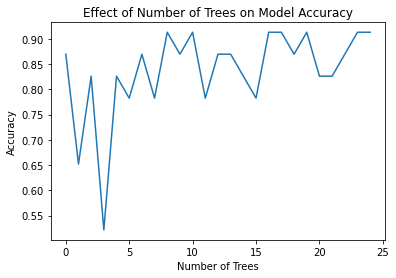

In [13]:
#Effect of no of trees on accuracy

trees=range(25)
accuracy=np.zeros(25)

for idx in range(len(trees)):
    classifier=RandomForestClassifier(n_estimators=idx + 1)
    classifier=classifier.fit(pred_train,tar_train)
    predictions=classifier.predict(pred_test)
    accuracy[idx]=sklearn.metrics.accuracy_score(tar_test, predictions)

plt.cla()
plt.plot(trees, accuracy)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Effect of Number of Trees on Model Accuracy')
plt.show()

**Interpretation:** This plot demonstrates how the model's accuracy changes as we increase the number of trees in the random forest. Generally, accuracy improves and stabilizes as more trees are added. The initial trees contribute significant improvements, but accuracy tends to plateau after a certain number of trees. This helps us determine the optimal balance between model complexity and performance. Too few trees may underfit the data, while too many trees increase computational cost without substantial accuracy gains.